# 晶体材料的形成能（Formation Energy per Atom）预测：基于 Matformer 的端到端推理示例

## 模型简介：什么是 Matformer？

**Matformer** 是一种专为**晶体材料**设计的图神经网络（Graph Neural Network, GNN），其核心思想是将晶体结构建模为**原子-键图**（Atom-Bond Graph），通过学习原子间相互作用来预测材料的物理化学性质。

### 核心特点：

- **图结构建模**：  
  将每个原子视为图中的节点，原子间的化学键视为边，晶格向量作为全局特征，构建一个**周期性图网络**。

- **多尺度注意力机制**：  
  引入注意力权重，自动学习哪些原子或键对目标性质（如形成能）影响更大。

- **可扩展性强**：  
  支持多种材料数据库（如 Materials Project、OQMD），可预测形成能、带隙、弹性模量等多种性质。

> 参考论文:
> "Periodic Graph Transformers for Crystal Material Property Prediction"  

本 Notebook 展示如何使用Matformer 模型，对晶体材料的 **形成能（Formation Energy per Atom）** 进行推理，并可视化预测结果与晶体结构。

In [1]:
!pip install pymatgen matplotlib ase numpy pydantic==1.10.9 jarvis-tools==2022.9.16 pathos

In [2]:
import os
import pickle
import yaml
import numpy as np
import mindspore as ms
from mindspore import set_seed
from mindspore import nn
from mindspore.amp import all_finite
from models.matformer import Matformer
from models.utils import LossRecord, OneCycleLr
from models.graph.loss import L1LossMask, L2LossMask
from models.graph.dataloader import DataLoaderBase as DataLoader

config_path = "config.yaml" # 加载配置文件
with open(config_path, 'r', encoding='utf-8') as stream:
    config = yaml.safe_load(stream)

device_target = config['train']["device"]  # "Ascend"
device_id = config['train']["device_id"]
ms.set_context(device_target=device_target, device_id=device_id)
set_seed(config['train']["seed"])

/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
[WARNING] ME(147086:281473265917984,MainProces

## 数据集说明：`jdft_3d-12-12-2022.json`

### 基本信息

- **数据集名称**：`jdft_3d-12-12-2022.json`
- **数据来源**：[JARVIS-DFT](https://jarvis.nist.gov/)（Joint Automated Repository for Various Integrated Simulations - Density Functional Theory）
- **数据规模**：共 **75,993** 个三维晶体结构
- **数据格式**：JSON 格式
- **材料标识**：使用 `jid`（如 `JVASP-90856`）作为唯一 ID

---

### 数据内容概览

该数据集包含通过密度泛函理论（DFT）计算的 **三维体相材料**（3D-bulk）的结构与性质，适用于材料发现、性质预测、机器学习建模等任务。

---

### 主要字段说明

| 字段名 | 类型 | 说明 |
|-------|------|------|
| `jid` | str | JARVIS 唯一材料 ID（如 `JVASP-90856`） |
| `formula` | str | 化学式（如 `TiCuSiAs`） |
| `spg_number` / `spg_symbol` | int / str | 空间群编号与符号（如 129, `P4/nmm`） |
| `formation_energy_peratom` | float | 每原子生成能（eV/atom），越负越稳定 |
| `optb88vdw_bandgap` | float | OptB88vdW 泛函计算的带隙（eV） |
| `mbj_bandgap`, `hse_gap` | float | mBJ 或 HSE06 泛函计算的带隙（部分材料有） |
| `atoms` | dict | **核心结构字段**，包含：<br>• `lattice_mat`: 晶格矩阵（3×3）<br>• `coords`: 原子坐标<br>• `elements`: 元素列表<br>• `cartesian`: 坐标是否为笛卡尔坐标（bool） |
| `density` | float | 材料密度（g/cm³） |
| `ehull` | float | 凸包能（eV/atom），< 0.1 eV/atom 视为稳定 |
| `func` | str | 使用的 DFT 泛函（如 `OptB88vdW`） |
| `dimensionality` | str | 材料维度（本集均为 `3D-bulk`） |
| `crys` | str | 晶系（如 `tetragonal`, `cubic`） |
| `nat` | int | 原子总数 |
| `reference` | str | 对应的 Materials Project ID（如 `mp-1080455`） |

---

### 构建数据集

本项目主要是预测晶体的formation_energy_peratom信息  
输入：原子 + 晶格信息 → 图结构  
输出：对应 target 属性（`formation_energy_peratom`）  
模型并不直接使用这些属性作为输入，而是从`atoms`字段构建晶体图，也就是图结构输入，所以如果自定义数据集，`atoms`字段是必须有的。  
参考本次模型的训练目标`formation_energy_peratom`所以使用的主要是数据集的一下字段。所以如果想要自定义数据集最少要有以下字段。  

```json
[
  {
  "jid": "EXAMPLE-0001",
  "nat": 4,
  "atoms": {'abc': [3.56693, 3.56693, 9.39708],
           'angles': [90.0, 90.0, 90.0],
           'cartesian': True,
           'coords': [[2.6751975000000003,
                       2.6751975000000003,
                       7.376101754328542],
                      [0.8917325, 0.8917325, 2.0209782456714573],
                      [0.8917325, 2.6751975000000003, 4.69854],
                      [2.6751975000000003, 0.8917325, 4.69854],
                      [0.8917325, 2.6751975000000003, 0.0],
                      [2.6751975000000003, 0.8917325, 0.0],
                      [2.6751975000000003,
                       2.6751975000000003,
                       2.8894795605846353],
                      [0.8917325, 0.8917325, 6.507600439415366]],
           'elements': ['Ti', 'Ti', 'Cu', 'Cu', 'Si', 'Si', 'As', 'As'],
           'lattice_mat': [[3.566933224304235, 0.0, -0.0],
                           [0.0, 3.566933224304235, -0.0],
                           [-0.0, -0.0, 9.397075454186664]],
           'props': ['', '', '', '', '', '', '', '']},
  "formation_energy_peratom": -1.23
},......]

```

如果想要去实现其他任务，可以参考上述来将目标字段替换掉，如将`formation_energy_peratom`换成`optb88vdw_bandgap`来预测带隙。

```json
{
  "jid": "CUSTOM-00002",
  "nat": 4,
  "atoms": {...},
  "optb88vdw_bandgap": 1.73
}
```



In [3]:
from data.generate import get_prop_model
# 创建目录
dataset_dir = config['train']["dataset_dir"]
ckpt_dir = config['train']["ckpt_dir"]
os.makedirs(dataset_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

# 生成/验证数据集
get_prop_model(prop=config['train']["props"], use_lattice=True, dataset_path=config["dataset"])

In [4]:
# 加载数据
with open(config['dataset']['x_train_path'], 'rb') as f:
    x = pickle.load(f)
with open(config['dataset']['edge_index_train_path'], 'rb') as f:
    edge_index = pickle.load(f)
with open(config['dataset']['edge_attr_train_path'], 'rb') as f:
    edge_attr = pickle.load(f)
with open(config['dataset']['label_train_path'], 'rb') as f:
    label = pickle.load(f)

# 加载验证集数据
with open(config['dataset']['x_val_path'], 'rb') as f:
    x_val = pickle.load(f)
with open(config['dataset']['edge_index_val_path'], 'rb') as f:
    edge_index_val = pickle.load(f)
with open(config['dataset']['edge_attr_val_path'], 'rb') as f:
    edge_attr_val = pickle.load(f)
with open(config['dataset']['label_val_path'], 'rb') as f:
    label_val = pickle.load(f)

# 初始化模型
matformer = Matformer(config['model'])
model_parameters = filter(lambda p: p.requires_grad, matformer.get_parameters())
params = sum(np.prod(p.shape) for p in model_parameters)
print("Model trainable parameters: %s", params)

# 优化器配置（权重衰减分组）
no_decay_params = list(filter(lambda x: 'bias' in x.name or 'norm' in x.name or 'bn' in x.name, matformer.trainable_params()))
decay_params = list(filter(lambda x: 'bias' not in x.name and 'norm' not in x.name and 'bn' not in x.name, matformer.trainable_params()))
group_params = [{'params': decay_params, 'weight_decay': 0.00001},
                {'params': no_decay_params, 'weight_decay': 0},
                {'order_params': matformer.trainable_params()}]
optimizer = nn.AdamWeightDecay(params=group_params, eps=0.00000001)
optimizer.beta1 = ms.Tensor([0.95], ms.float32)

# 损失函数
loss_func_mse = L2LossMask(reduction='mean')
loss_func_mae = L1LossMask(reduction='mean')

# 定义前向传播
def forward(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size):
    pred = matformer(data_x, data_edge_attr, data_edge_index, data_batch, node_mask, edge_mask, node_num)
    mseloss = loss_func_mse(pred, data_label, num=batch_size)
    return mseloss, pred

# 反向传播
backward = ms.value_and_grad(forward, None, weights=matformer.trainable_params(), has_aux=True)

# 训练步
def train_step(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size):
    (mseloss, pred), grads = backward(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size)
    is_finite = all_finite(grads)
    if is_finite:
        optimizer(grads)
    return mseloss, is_finite, pred

# 验证步
def forward_eval(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size):
    pred = matformer(data_x, data_edge_attr, data_edge_index, data_batch, node_mask, edge_mask, node_num)
    mseloss = loss_func_mse(pred, data_label, num=batch_size)
    maeloss = loss_func_mae(pred, data_label, num=batch_size)
    return mseloss, maeloss, pred


def eval_step(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size):
    return forward_eval(data_x, data_edge_attr, data_edge_index, data_batch, data_label, node_mask, edge_mask, node_num, batch_size)

# 创建数据加载器
BATCH_SIZE = config['train']['batch_size']
train_loader = DataLoader(BATCH_SIZE, edge_index, node_attr=x, edge_attr=edge_attr, label=label, dynamic_batch_size=True)
eval_loader = DataLoader(BATCH_SIZE, edge_index_val, node_attr=x_val, edge_attr=edge_attr_val, label=label_val, dynamic_batch_size=False)

# 学习率调度
one_cycle_lr_cls = OneCycleLr(steps_per_epoch=int(len(label) / BATCH_SIZE), epochs=config['train']["epoch_size"], max_lr=0.001, optimizer=optimizer)

# 检查是否已有训练模型
if os.path.exists(config['checkpoint']['best_loss_path']):
    print("Loading existing checkpoint from: %s", config['checkpoint']['best_loss_path'])
    param_dict = ms.load_checkpoint(config['checkpoint']['best_loss_path'])
    epoch = int(param_dict["epoch"]) + 1
    param_not_load, _ = ms.load_param_into_net(matformer, param_dict)
    one_cycle_lr_cls.current_step = int(param_dict["current_step"])
    one_cycle_lr_cls.step()
    print("Resuming training from epoch: %d", epoch)
else:
    print("Starting new training process")
    epoch = 0

# 训练主循环
BEST_EPOCH_EVAL_MSE_LOSS = float('inf')
for epoch in range(epoch, config['train']["epoch_size"]):
    # 训练
    matformer.set_train(True)
    train_mseloss_record = LossRecord()
    for batch in train_loader:
        (x, edge_attr, y, edge_idx, batch_idx, node_mask, edge_mask, node_num, bs) = batch
        mseloss, is_finite, _ = train_step(x, edge_attr, edge_idx, batch_idx, y, node_mask, edge_mask, node_num, bs)
        train_mseloss_record.update(mseloss)
    # 验证
    matformer.set_train(False)
    eval_mseloss_record = LossRecord()
    eval_maeloss_record = LossRecord()
    for batch in eval_loader:
        (x, edge_attr, y, edge_idx, batch_idx, node_mask, edge_mask, node_num, bs) = batch
        mseloss, maeloss, _ = eval_step(x, edge_attr, edge_idx, batch_idx, y, node_mask, edge_mask, node_num, bs)
        eval_mseloss_record.update(mseloss)
        eval_maeloss_record.update(maeloss)
    # 保存最佳模型
    if eval_mseloss_record.avg < BEST_EPOCH_EVAL_MSE_LOSS:
        BEST_EPOCH_EVAL_MSE_LOSS = eval_mseloss_record.avg
        state = {"epoch": str(epoch), "current_step": str(one_cycle_lr_cls.current_step)}
        ms.save_checkpoint(matformer, config['checkpoint']['best_loss_path'], append_dict=state)
        print("Saved best model at epoch %d, MSE: %.6f", epoch, eval_mseloss_record.avg)

    print(f"Epoch {epoch} | Train MSE: {train_mseloss_record.avg.item():.6f} | Val MSE: {eval_mseloss_record.avg.item():.6f} | Val MAE: {eval_maeloss_record.avg.item():.6f}")
print("Training completed. Best model saved to: %s", config['checkpoint']['best_loss_path'])

Model trainable parameters: %s 2786689
Loading existing checkpoint from: %s ./ckpt/best_matformer.ckpt
Resuming training from epoch: %d 1
Training completed. Best model saved to: %s ./ckpt/best_matformer.ckpt


In [5]:
# 打印参数量
model_parameters = filter(lambda p: p.requires_grad, matformer.get_parameters())
params = sum(np.prod(p.shape) for p in model_parameters)
print("The model has %s parameters.", params)

# 定义损失函数
loss_func_mse = L2LossMask(reduction='mean')
loss_func_mae = L1LossMask(reduction='mean')

# 加载 checkpoint
checkpoint_dir = config['predictor']['checkpoint_path']

if not os.path.exists(checkpoint_dir):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_dir}")

print("Loading checkpoint from: %s", checkpoint_dir)
param_dict = ms.load_checkpoint(checkpoint_dir)
param_not_load, _ = ms.load_param_into_net(matformer, param_dict)
if param_not_load:
    print("Some parameters were not loaded: %s", param_not_load)

matformer.set_train(False)  # 切换到推理模式

The model has %s parameters. 2786689
Loading checkpoint from: %s ./ckpt/best_matformer.ckpt


Matformer(
  (atom_embedding): Dense(input_channels=92, output_channels=128, has_bias=True)
  (rbf_0): RBFExpansion()
  (rbf_1): Dense(input_channels=128, output_channels=128, has_bias=True)
  (rbf_3): Dense(input_channels=128, output_channels=128, has_bias=True)
  (att_layers): CellList(
    (0): MatformerConv(128, 128, heads=4)
    (1): MatformerConv(128, 128, heads=4)
    (2): MatformerConv(128, 128, heads=4)
    (3): MatformerConv(128, 128, heads=4)
    (4): MatformerConv(128, 128, heads=4)
  )
  (fc): SequentialCell(
    (0): Dense(input_channels=128, output_channels=128, has_bias=True)
    (1): Silu(
      (sigmoid): Sigmoid()
    )
  )
  (fc_out): Dense(input_channels=128, output_channels=1, has_bias=True)
  (aggregator_to_global): AggregateNodeToGlobal()
)

In [6]:
def forward_eval(data_x, data_edge_attr, data_edge_index, data_batch, data_label,
                 node_mask, edge_mask, node_num, batch_size):
    pred = matformer(data_x, data_edge_attr, data_edge_index, data_batch,
                     node_mask, edge_mask, node_num)
    mseloss = loss_func_mse(pred, data_label, num=batch_size)
    maeloss = loss_func_mae(pred, data_label, num=batch_size)
    return mseloss, maeloss, pred

eval_step = forward_eval

In [7]:
# 推理
# 初始化 DataLoader
BATCH_SIZE_MAX = config['train']['batch_size']
eval_loader = DataLoader(
    BATCH_SIZE_MAX,
    edge_index_val,
    node_attr=x_val,
    edge_attr=edge_attr_val,
    label=label_val,
    dynamic_batch_size=False,
    shuffle_dataset=False
)

# 存储所有预测结果和标签（用于后续分析/绘图）
all_preds = []
all_labels = []

eval_mseloss_record = LossRecord()
eval_maeloss_record = LossRecord()

print("Starting inference...")

for batch in eval_loader:
    (node_attr_step, edge_attr_step, label_step, edge_index_step,
     node_batch_step, node_mask_step, edge_mask_step, node_num_step, batch_size_step) = batch

    mseloss_step, maeloss_step, pred_step = eval_step(
        node_attr_step, edge_attr_step, edge_index_step, node_batch_step,
        label_step, node_mask_step, edge_mask_step, node_num_step, batch_size_step
    )

    # 累积损失
    eval_mseloss_record.update(mseloss_step)
    eval_maeloss_record.update(maeloss_step)

    # 保存预测值和真实值（转为 numpy 便于分析）
    all_preds.append(pred_step.asnumpy())
    all_labels.append(label_step.asnumpy())

    print("Batch MSE: %.6f, MAE: %.6f", mseloss_step.asnumpy(), maeloss_step.asnumpy())

# 合并结果
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Inference completed.")
print("Average MSE: %.6f", eval_mseloss_record.avg)
print("Average MAE: %.6f", eval_maeloss_record.avg)

Starting inference...
Batch MSE: %.6f, MAE: %.6f 0.043750834 0.14395
Batch MSE: %.6f, MAE: %.6f 0.10943773 0.18327576
Batch MSE: %.6f, MAE: %.6f 0.039151095 0.14835942
Batch MSE: %.6f, MAE: %.6f 0.043602776 0.13516876
Batch MSE: %.6f, MAE: %.6f 0.041445397 0.14045432
Batch MSE: %.6f, MAE: %.6f 0.036282226 0.13990684
Batch MSE: %.6f, MAE: %.6f 0.047720864 0.14253876
Batch MSE: %.6f, MAE: %.6f 0.03105317 0.12102785
Batch MSE: %.6f, MAE: %.6f 0.02921421 0.11850074
Batch MSE: %.6f, MAE: %.6f 0.11715439 0.17308599
Batch MSE: %.6f, MAE: %.6f 0.043699227 0.16304001
Batch MSE: %.6f, MAE: %.6f 0.08008011 0.16171753
Batch MSE: %.6f, MAE: %.6f 0.069183365 0.1429166
Batch MSE: %.6f, MAE: %.6f 0.042589102 0.1505639
Batch MSE: %.6f, MAE: %.6f 0.046605058 0.16049895
Batch MSE: %.6f, MAE: %.6f 0.042094924 0.14214431
Batch MSE: %.6f, MAE: %.6f 0.03430771 0.13636498
Batch MSE: %.6f, MAE: %.6f 0.036877137 0.1417602
Batch MSE: %.6f, MAE: %.6f 0.053245373 0.12846707
Batch MSE: %.6f, MAE: %.6f 0.068187326 0

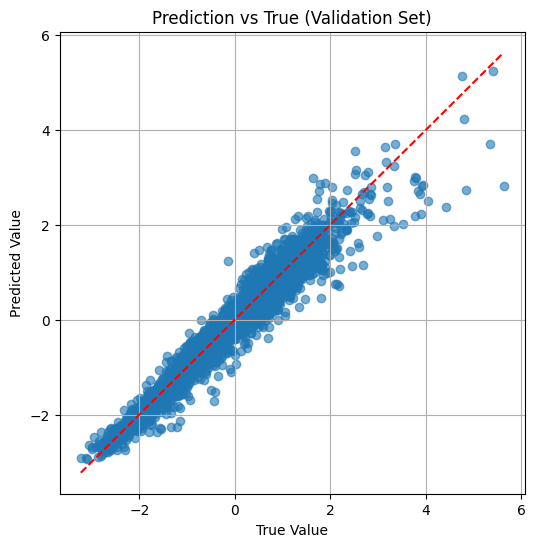

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt



plt.figure(figsize=(6, 6))
plt.scatter(all_labels, all_preds, alpha=0.6)
plt.plot([all_labels.min(), all_labels.max()], [all_labels.min(), all_labels.max()], 'r--')
plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Prediction vs True (Validation Set)')
plt.grid(True)
plt.show()

### 展示晶体图结构

数据集加载完成，共 75993 条记录


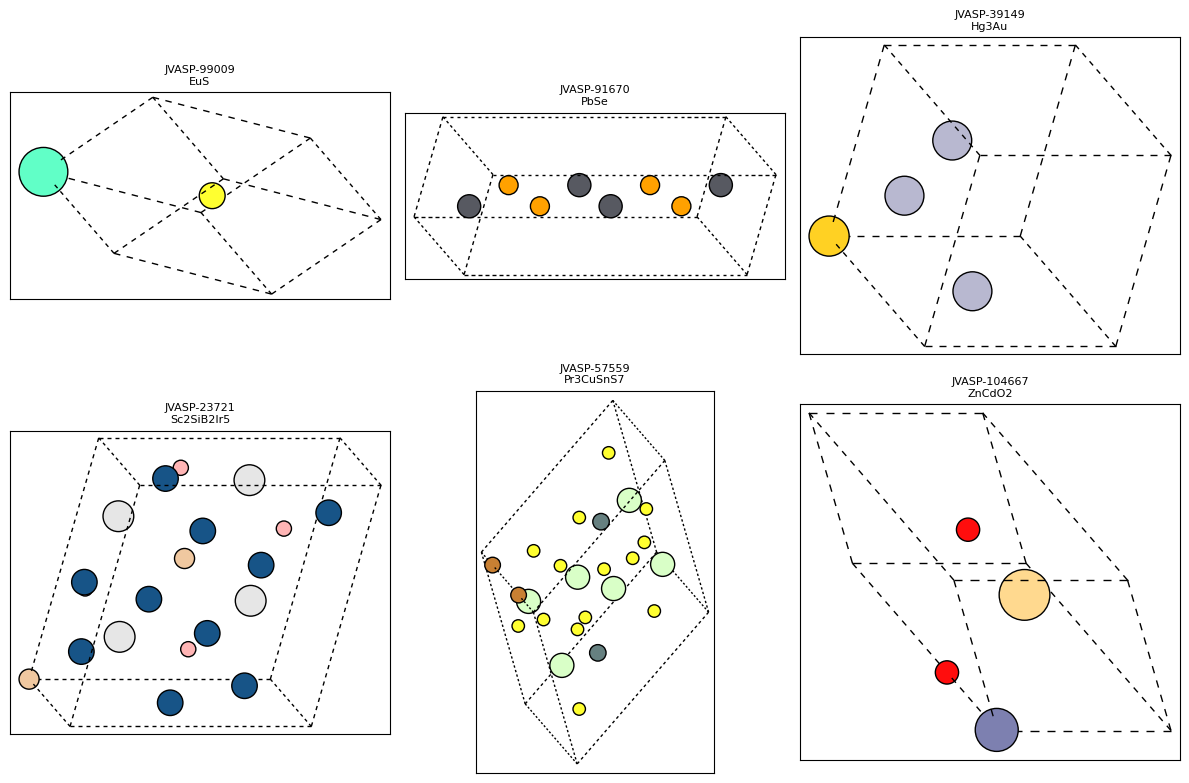

In [9]:
import json
import random

from ase import Atoms
from ase.visualize.plot import plot_atoms

# 参数
json_path = "jdft_3d-12-12-2022.json"  # 替换为你的路径

n = 6  # 挑选样本数量
seed = 42
figsize_each = (4, 4)  # 每个子图大小（英寸）

# 读取数据
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

total = len(data)
print(f"数据集加载完成，共 {total} 条记录")

# 随机挑选 n 条（若样本少则取全部）
random.seed(seed)
indices = random.sample(range(total), k=min(n, total))


def build_ase_atoms_from_atoms_block(atoms_block):
    lattice = np.array(atoms_block["lattice_mat"], dtype=float)
    elements = atoms_block["elements"]
    coords = np.array(atoms_block["coords"], dtype=float)
    cartesian_flag = bool(atoms_block.get("cartesian", True))

    if not cartesian_flag:

        coords = np.dot(coords, lattice)

    ase_atoms = Atoms(symbols=elements, positions=coords, cell=lattice, pbc=True)
    return ase_atoms

cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_each[0], rows * figsize_each[1]))
axes = axes.flatten()

for ax_idx, idx in enumerate(indices):
    sample = data[idx]
    jid = sample.get("jid", f"sample_{idx}")
    formula = sample.get("formula", "")
    atoms_block = sample["atoms"]

    try:
        ase_atoms = build_ase_atoms_from_atoms_block(atoms_block)
    except Exception as e:
        print(f"⚠️ 解析样本 {jid} 出错，跳过：{e}")
        axes[ax_idx].axis("off")
        continue

    plot_atoms(ase_atoms, ax=axes[ax_idx], radii=0.3, rotation="30x,30y,0z")
    axes[ax_idx].set_title(f"{jid}\n{formula}", fontsize=8)
    axes[ax_idx].set_xticks([])
    axes[ax_idx].set_yticks([])

# 关闭剩余空子图
for j in range(len(indices), rows * cols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

